<a href="https://colab.research.google.com/github/hemantofficiall009-ctrl/Heart-disease/blob/main/heart_disease_numpy_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Load the Heart Disease UCI dataset (CSV) using only NumPy. Compute: mean and std of each feature column, correlation between age and max heart rate, normalize all columns to 0–1 range. Save your notebook as numpy_eda.ipynb and push to GitHub with a README.**

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
path = '/content/drive/My Drive/Colab Notebooks/heart.csv'
data = np.genfromtxt(path, delimiter=',', skip_header=1)
print(data.shape)

(303, 14)


In [23]:
plt.savefig('/content/drive/My Drive/Colab Notebooks/heart_eda.png', dpi=150)

<Figure size 640x480 with 0 Axes>

In [24]:
data = np.genfromtxt('heart.csv', delimiter=',', skip_header=1)
print("Shape:", data.shape)
print("NaN count:", np.isnan(data).sum())

Shape: (303, 14)
NaN count: 0


In [25]:
X = data[:, :13]   # features
y = data[:, 13]    # target (0 or 1)
cols = ['age','sex','cp','trestbps','chol',
        'fbs','restecg','thalach','exang',
        'oldpeak','slope','ca','thal']

In [26]:
print(f"{'Feature':12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
for i, col in enumerate(cols):
    print(f"{col:12} {X[:,i].mean():>8.2f} {X[:,i].std():>8.2f}"
          f" {X[:,i].min():>8.2f} {X[:,i].max():>8.2f}")

Feature          Mean      Std      Min      Max
age             53.84     8.66    29.00    77.00
sex              0.69     0.46     0.00     1.00
cp               0.88     0.99     0.00     3.00
trestbps       133.55    16.55    94.00   176.00
chol           248.14    52.05   126.00   379.00
fbs              0.13     0.33     0.00     1.00
restecg          0.56     0.54     0.00     2.00
thalach        148.45    21.88    80.00   202.00
exang            0.36     0.48     0.00     1.00
oldpeak          1.09     0.98     0.00     6.20
slope            1.11     0.71     0.00     2.00
ca               0.70     0.98     0.00     3.00
thal             2.09     0.56     0.00     3.00


In [27]:
disease    = data[y == 1]
no_disease = data[y == 0]
print(f"Patients with disease:    {len(disease)}")
print(f"Patients without disease: {len(no_disease)}")
print(f"Avg age (disease):    {disease[:,0].mean():.1f}")
print(f"Avg age (no disease): {no_disease[:,0].mean():.1f}")
print(f"Avg max HR (disease):    {disease[:,7].mean():.1f}")
print(f"Avg max HR (no disease): {no_disease[:,7].mean():.1f}")

Patients with disease:    182
Patients without disease: 121
Avg age (disease):    56.9
Avg age (no disease): 49.3
Avg max HR (disease):    142.3
Avg max HR (no disease): 157.7


In [28]:
col_min = X.min(axis=0)
col_max = X.max(axis=0)
X_norm  = (X - col_min) / (col_max - col_min)
print("All mins after norm:", X_norm.min(axis=0))
print("All maxs after norm:", X_norm.max(axis=0))

All mins after norm: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
All maxs after norm: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [29]:
corr = np.corrcoef(X[:,0], X[:,7])[0,1]
print(f"Correlation (age vs thalach): {corr:.3f}")

Correlation (age vs thalach): -0.084


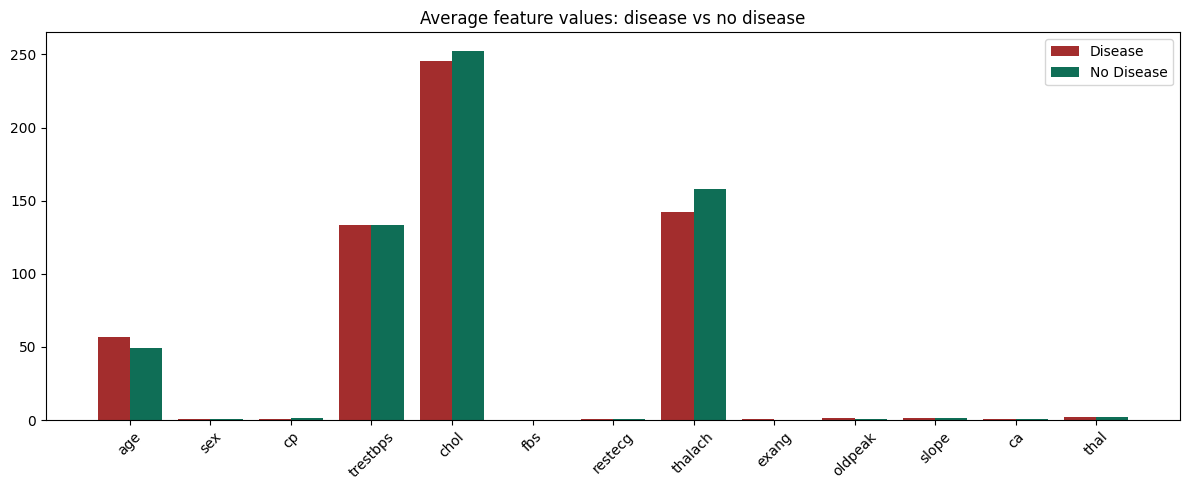

In [30]:
means_d  = disease.mean(axis=0)[:13]
means_nd = no_disease.mean(axis=0)[:13]
x_pos = np.arange(len(cols))

plt.figure(figsize=(12, 5))
plt.bar(x_pos - 0.2, means_d,  0.4, label='Disease',    color='#A32D2D')
plt.bar(x_pos + 0.2, means_nd, 0.4, label='No Disease', color='#0F6E56')
plt.xticks(x_pos, cols, rotation=45)
plt.legend()
plt.title('Average feature values: disease vs no disease')
plt.tight_layout()
plt.savefig('heart_eda.png')
plt.show()